In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr



In [2]:
yeast_pool_A_activities = pd.read_csv("../../../output/GCN4_pipeline/trebl_experiment_pool_A_results_per_barcode.csv", index_col = 0)
yeast_pool_A_activities

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT,activity
5,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,25.0,3,0,182.0,7.280000
6,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,37.0,3,5,154.0,4.162162
7,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,52.0,3,10,285.0,5.480769
8,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,45.0,3,240,248.0,5.511111
9,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,45.0,3,240,236.0,5.244444
...,...,...,...,...,...,...,...,...
15221,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,284.0,3,10,170.0,0.598592
15222,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0,0.313433
15223,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0,0.313433
15224,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,307.0,3,240,126.0,0.410423


In [3]:
yeast_pool_B_activities = pd.read_csv("../../../output/GCN4_pipeline/trebl_experiment_pool_B_results_per_barcode.csv", index_col = 0)
yeast_pool_B_activities

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT,activity
0,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,131.0,2,0,114.0,0.870229
1,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,228.0,2,5,167.0,0.732456
2,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,363.0,2,10,104.0,0.286501
6,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,233.0,3,0,142.0,0.609442
7,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,257.0,3,5,138.0,0.536965
...,...,...,...,...,...,...,...,...
71351,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,36755.0,4,5,22387.0,0.609087
71352,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,39135.0,4,10,16032.0,0.409659
71353,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,40674.0,4,15,12838.0,0.315632
71354,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,41958.0,4,30,11531.0,0.274822


In [4]:
yeast_pool_C_PolyT_activities = pd.read_csv("../../../output/GCN4_pipeline/trebl_experiment_pool_C_PolyT_results_per_barcode.csv", index_col = 0)
yeast_pool_C_PolyT_activities

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT,activity
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,122.0,2,0,101.0,0.827869
1,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,203.0,2,5,72.0,0.354680
2,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,180.0,2,10,56.0,0.311111
3,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,174.0,2,15,53.0,0.304598
4,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,129.0,2,30,33.0,0.255814
...,...,...,...,...,...,...,...,...
387193,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,685.0,4,10,627.0,0.915328
387194,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,671.0,4,15,817.0,1.217586
387195,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,591.0,4,30,695.0,1.175973
387196,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,626.0,4,180,389.0,0.621406


In [5]:
activities_A_B = pd.merge(yeast_pool_A_activities[["AD", "AD_BC", "RPTR_BC", "rep", "time", "activity"]],
                            yeast_pool_B_activities[["AD", "AD_BC", "RPTR_BC", "rep", "time", "activity"]], 
                            on = ["AD", "AD_BC", "RPTR_BC", "rep", "time"],
                            suffixes = ["_A", "_B"],
                            how = 'outer')
activities_A_B

,AD,AD_BC,RPTR_BC,rep,time,activity_A,activity_B
0,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,0,7.280000,2.539136
1,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,5,4.162162,2.965033
2,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,10,5.480769,3.875105
3,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,240,5.511111,NaN
4,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,240,5.244444,NaN
...,...,...,...,...,...,...,...
45176,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,4,5,NaN,0.609087
45177,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,4,10,NaN,0.409659
45178,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,4,15,NaN,0.315632
45179,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,4,30,NaN,0.274822


In [6]:
activities_A_B_C_PolyT = pd.merge(activities_A_B,
                            yeast_pool_C_PolyT_activities[["AD", "AD_BC", "RPTR_BC", "rep", "time", "activity"]], 
                            on = ["AD", "AD_BC", "RPTR_BC", "rep", "time"],
                            suffixes = ["", "_C_PolyT"],
                            how = 'outer')
activities_A_B_C_PolyT = activities_A_B_C_PolyT.rename(columns = {"activity" : "activity_C_PolyT"})
activities_A_B_C_PolyT

,AD,AD_BC,RPTR_BC,rep,time,activity_A,activity_B,activity_C_PolyT
0,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,0,7.280000,2.539136,1.053214
1,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,5,4.162162,2.965033,2.292671
2,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,10,5.480769,3.875105,2.795909
3,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,240,5.511111,NaN,2.342298
4,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,3,240,5.244444,NaN,2.342298
...,...,...,...,...,...,...,...,...
306570,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,4,10,NaN,NaN,0.915328
306571,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,4,15,NaN,NaN,1.217586
306572,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,4,30,NaN,NaN,1.175973
306573,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,ACCCATCCAGA,AAATATTTGTCCGC,4,180,NaN,NaN,0.621406


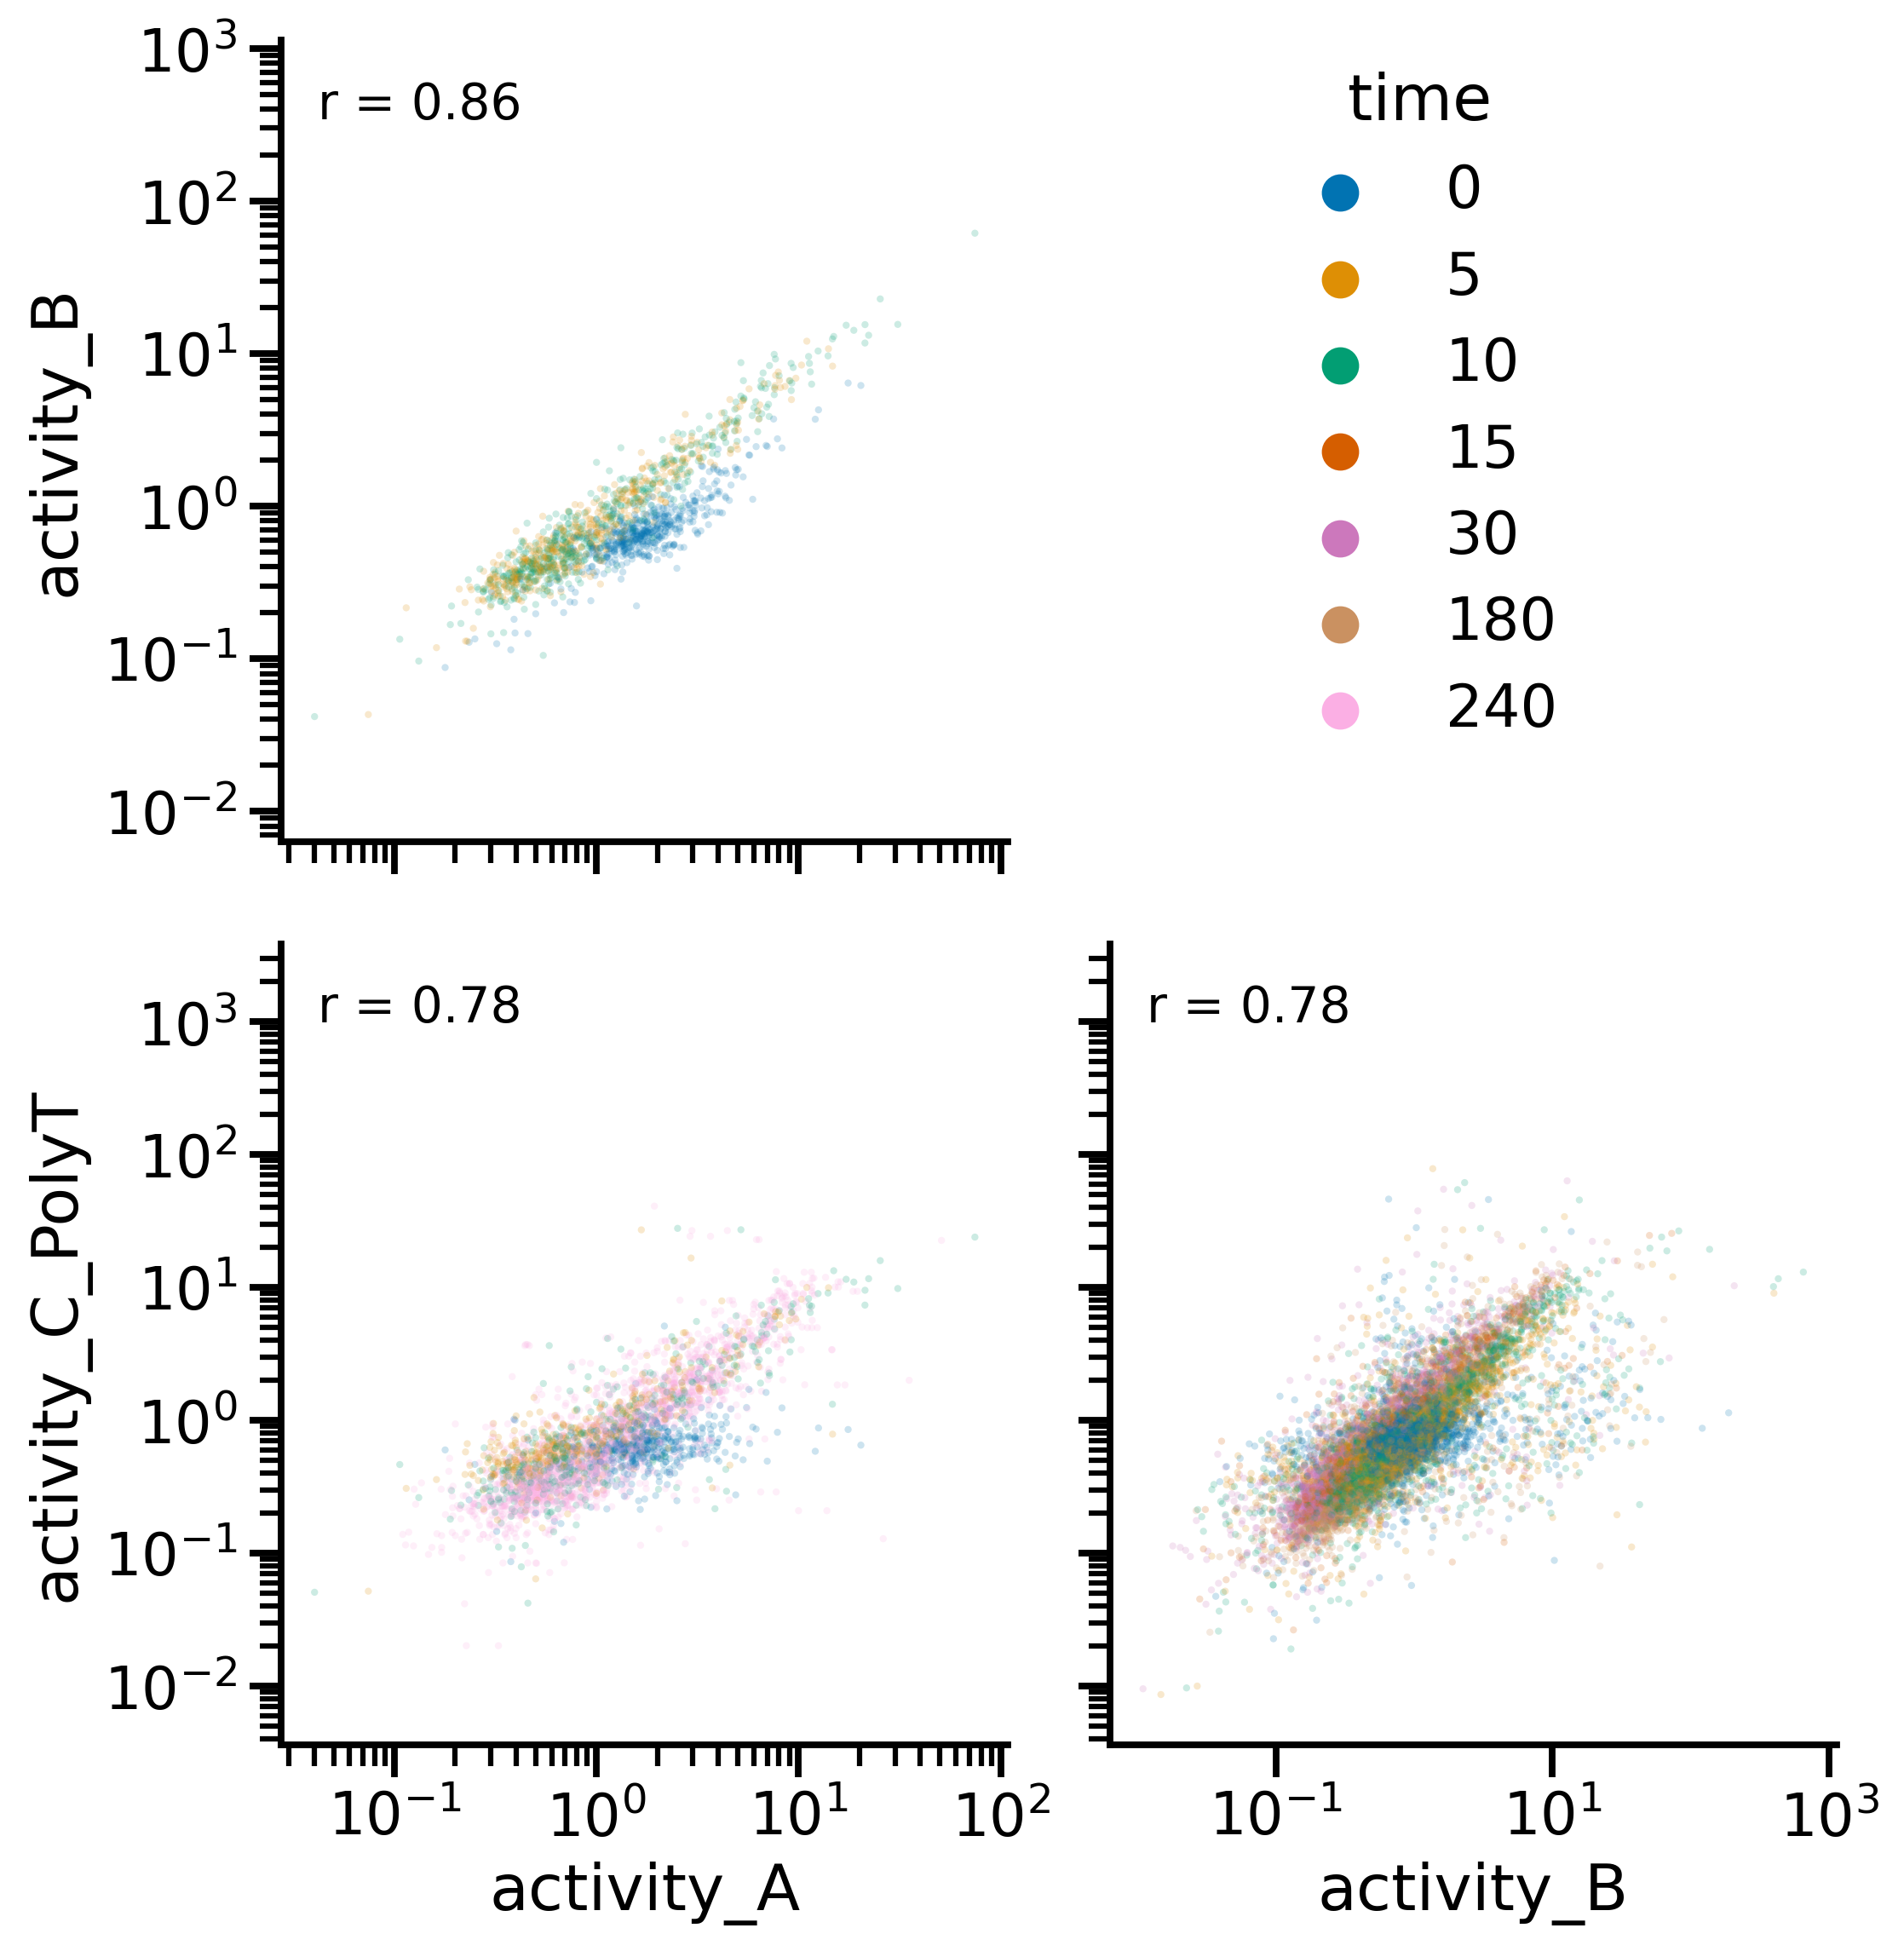

In [61]:
sns.set_context('talk')

cols = ["activity_A", "activity_B", "activity_C_PolyT", "time"]

df = activities_A_B_C_PolyT[cols].sample(100000)

g = sns.pairplot(
    df,
    corner=True,
    hue='time',
    diag_kind=None,
    plot_kws={"s": 4, "alpha": 0.2, "edgecolor": "none"},
    palette = 'colorblind'
)

g.fig.set_size_inches(14, 12)
g.fig.set_dpi(300)

# remove diagonal axes
for i in range(len(cols)-1):
    g.axes[i, i].set_visible(False)

# add correlations
activity_cols = ["activity_A", "activity_B", "activity_C_PolyT"]

for i in range(len(activity_cols)):
    for j in range(i):
        ax = g.axes[i, j]
        if ax is None:
            continue
        
        x = df[activity_cols[j]]
        y = df[activity_cols[i]]
        mask = x.notna() & y.notna()
        
        r, _ = spearmanr(x[mask], y[mask])
        
        ax.text(
            0.05, 0.95,
            f"r = {r:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14)

# log scale
for ax in g.axes.flatten():
    if ax is not None and ax.get_visible():
        ax.set_xscale("log")
        ax.set_yscale("log")

g._legend.set_bbox_to_anchor((0.45, 0.63))  # (x, y) in figure coordinates
g._legend.set_loc("upper right")        # anchor point of legend
plt.show()